<a href="https://colab.research.google.com/github/takuonakashima/ai-security-workshop/blob/main/FGSM_attack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 9.91M/9.91M [00:00<00:00, 39.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.12MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.69MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.2MB/s]


💉 AIにワクチン（通常の学習）を接種しています...
✅ 接種完了！ベースとなるAIが完成しました。

🛡️ ワクチン接種済みAIへのサイバー攻撃テストを開始します...
----------------------------------------
本当の正解: 『 7 』
❌ 防御失敗... 『 9 』に誤認識してしまいました。
----------------------------------------


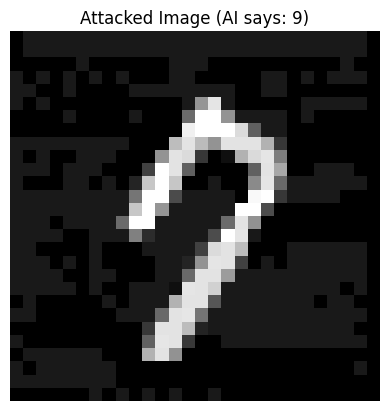

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ==========================================
# 1. 基本設定とデータの準備
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 画像を0〜1の範囲のテンソルに変換（ノイズ計算を分かりやすくするため）
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# ==========================================
# 2. モデルの定義 (SimpleCNN)
# ==========================================
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        return x

secure_model = SimpleCNN().to(device)

# ==========================================
# 3. ワクチン接種（事前学習）
# ==========================================
# AIがそもそも数字を認識できないと騙す意味がないため、短時間だけ学習させます
optimizer = optim.Adam(secure_model.parameters(), lr=0.001)
secure_model.train()
print("💉 AIにワクチン（通常の学習）を接種しています...")

# 処理時間を短くするため、100バッチ（6400枚）だけ学習して基礎知識をつけさせる
for i, (data, target) in enumerate(train_loader):
    data, target = data.to(device), target.to(device)
    optimizer.zero_grad()
    output = secure_model(data)
    loss = F.cross_entropy(output, target)
    loss.backward()
    optimizer.step()
    if i == 100:
        break

print("✅ 接種完了！ベースとなるAIが完成しました。\n")

# ==========================================
# 4. サイバー攻撃の手法（FGSM）の定義
# ==========================================
def fgsm_attack(image, epsilon, data_grad):
    # 勾配の符号（プラスかマイナスか）を取得
    sign_data_grad = data_grad.sign()
    # 元の画像に、AIが最も嫌がる方向のノイズを加える
    perturbed_image = image + epsilon * sign_data_grad
    # ピクセル値が0〜1の範囲を越えないように切り詰める
    perturbed_image = torch.clamp(perturbed_image, 0, 1)
    return perturbed_image

# ==========================================
# 5. ご提示いただいたテストコード（攻撃の実行）
# ==========================================
secure_model.eval() # 評価（テスト）モードに切り替え
print("🛡️ ワクチン接種済みAIへのサイバー攻撃テストを開始します...")

dataiter = iter(train_loader)
images, labels = next(dataiter)

# テスト用の画像を1枚取り出す
image = images[0].unsqueeze(0).to(device)
label = labels[0].unsqueeze(0).to(device)

# 攻撃の強さ（ノイズの大きさ。0.1〜0.3程度で実験すると面白いです）
epsilon = 0.1

# 重要：画像自体に対する勾配（弱点）を計算できるように設定
image.requires_grad = True

# 一度普通に推論し、AIの「弱点」を探る
output = secure_model(image)
loss = F.cross_entropy(output, label)
secure_model.zero_grad()
loss.backward()

# 画像のどのピクセルを弄ればAIが一番混乱するか（勾配データ）を取得
data_grad = image.grad.data

# FGSM攻撃関数を呼び出して、ノイズ入りの画像を生成
perturbed_data = fgsm_attack(image, epsilon, data_grad)

# 攻撃された画像をもう一度AIに見せる
output_adv = secure_model(perturbed_data)
max_prob_adv, predicted_adv = torch.max(F.softmax(output_adv, dim=1), 1)

print("-" * 40)
print(f"本当の正解: 『 {label.item()} 』")

if predicted_adv.item() == label.item():
    print(f"✅ 防御成功！ ノイズに騙されず『 {predicted_adv.item()} 』と見破りました！")
    print(f"   (確信度: {max_prob_adv.item()*100:.2f}%)")
else:
    print(f"❌ 防御失敗... 『 {predicted_adv.item()} 』に誤認識してしまいました。")

print("-" * 40)

# 結果の画像を表示
plt.imshow(perturbed_data.cpu().detach().squeeze().numpy(), cmap='gray')
plt.title(f"Attacked Image (AI says: {predicted_adv.item()})")
plt.axis('off')
plt.show()